<a href="https://colab.research.google.com/github/Juliana-Amorim/science-des-donn-es--ducation/blob/main/cluster_bac_filles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving mca_lycees_2023.xlsx to mca_lycees_2023.xlsx


In [2]:
import pandas as pd
cluster_bac_sexe = pd.read_excel("mca_lycees_2023.xlsx")

In [3]:
print(cluster_bac_sexe)

      num_ligne Rentrée scolaire    Académie       UAI  \
0          1128        2023-2024    GRENOBLE  0382895R   
1          1677        2023-2024  NANCY-METZ  0573320Z   
2          1836        2023-2024       LILLE  0595867G   
3          1848        2023-2024       LILLE  0597005U   
4          1977        2023-2024       LILLE  0623902E   
...         ...              ...         ...       ...   
1538       3071        2023-2024       DIJON  0890003V   
1539       3324        2023-2024     CRETEIL  0932667U   
1540       3490        2023-2024  GUADELOUPE  9710884J   
1541       3524        2023-2024  MARTINIQUE  9720692V   
1542       3603        2023-2024     MAYOTTE  9760127J   

                                 Nom de l'établissement Type de lycée  \
0                           LYCEE POLYVALENT PH DELORME           LPO   
1     LYCEE POLYVALENT RAYMOND MONDON LYCEE DES METI...           LPO   
2     LYCEE GENERAL ET TECHNOLOGIQUE INTERNATIONAL M...          LEGT   
3          

In [4]:
cluster_bac_sexe["prop_filles"] = cluster_bac_sexe["élèves.filles"]/cluster_bac_sexe["Nombre.élèves"]*100


In [5]:
print(cluster_bac_sexe["prop_filles"])

0       38.654618
1        0.000000
2       57.816006
3       47.945205
4       37.869822
          ...    
1538    60.813953
1539    42.213115
1540    38.509317
1541    54.789272
1542    43.535396
Name: prop_filles, Length: 1543, dtype: float64


In [6]:
cluster_bac_sexe['prop_filles'] = cluster_bac_sexe["élèves.filles"]/cluster_bac_sexe["Nombre.élèves"]*100

In [7]:
print(cluster_bac_sexe)

      num_ligne Rentrée scolaire    Académie       UAI  \
0          1128        2023-2024    GRENOBLE  0382895R   
1          1677        2023-2024  NANCY-METZ  0573320Z   
2          1836        2023-2024       LILLE  0595867G   
3          1848        2023-2024       LILLE  0597005U   
4          1977        2023-2024       LILLE  0623902E   
...         ...              ...         ...       ...   
1538       3071        2023-2024       DIJON  0890003V   
1539       3324        2023-2024     CRETEIL  0932667U   
1540       3490        2023-2024  GUADELOUPE  9710884J   
1541       3524        2023-2024  MARTINIQUE  9720692V   
1542       3603        2023-2024     MAYOTTE  9760127J   

                                 Nom de l'établissement Type de lycée  \
0                           LYCEE POLYVALENT PH DELORME           LPO   
1     LYCEE POLYVALENT RAYMOND MONDON LYCEE DES METI...           LPO   
2     LYCEE GENERAL ET TECHNOLOGIQUE INTERNATIONAL M...          LEGT   
3          

In [8]:
cluster_bac_sexe = cluster_bac_sexe[cluster_bac_sexe['prop_filles'] != 0]

In [9]:
cluster_bac_sexe = cluster_bac_sexe.drop(columns=["num_ligne","Académie","Type de lycée","IPS voie GT","Nombre.élèves","élèves.filles","élèves.garçons"])

In [10]:
cluster_bac_sexe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1513 entries, 0 to 1542
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Rentrée scolaire        1513 non-null   object 
 1   UAI                     1513 non-null   object 
 2   Nom de l'établissement  1513 non-null   object 
 3   Taux d'accès 2nde-bac   1513 non-null   int64  
 4   prop_filles             1513 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 70.9+ KB


In [11]:
cluster_bac_sexe.describe()

,Taux d'accès 2nde-bac,prop_filles
count,1513.000000,1513.000000
mean,83.863847,43.925479
std,6.251981,10.172607
min,43.000000,1.777778
25%,81.000000,40.422078
50%,85.000000,45.277361
75%,88.000000,49.914237
max,100.000000,75.777414


In [12]:
cluster_bac_sexe_num = cluster_bac_sexe.drop(columns=["Rentrée scolaire", "UAI", "Nom de l'établissement"])

In [13]:
cluster_bac_sexe.to_excel("cluster_bac_sexe.xlsx", index=False)

In [14]:
!pip install pandas
!pip install numpy
!pip install scipy
!pip install plotly
!pip install seaborn
!pip install matplotlib
!pip install statsmodels
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 5.6 MB/s eta 0:00:00


In [15]:
import pandas as pd
import numpy as np
import scipy
from scipy.stats import chi2_contingency
from scipy.stats import zscore
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import prince
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

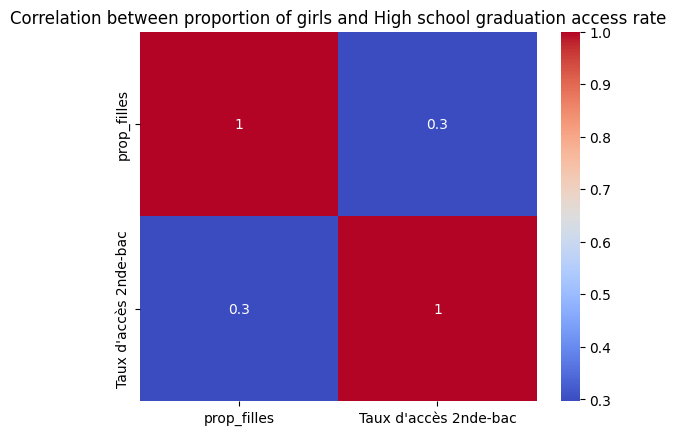

In [16]:
corr = cluster_bac_sexe[['prop_filles', "Taux d'accès 2nde-bac"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between proportion of girls and High school graduation access rate")
plt.show()

In [17]:
cluster_bac_sexe = cluster_bac_sexe.drop(columns=["Rentrée scolaire", "UAI","Nom de l'établissement"])

In [18]:
print(cluster_bac_sexe)

      Taux d'accès 2nde-bac  prop_filles
0                        85    38.654618
2                        78    57.816006
3                        86    47.945205
4                        74    37.869822
5                        85    43.976494
...                     ...          ...
1538                     89    60.813953
1539                     90    42.213115
1540                     90    38.509317
1541                     97    54.789272
1542                     76    43.535396

[1513 rows x 2 columns]


In [19]:
cluster_bac_sexe_pad = cluster_bac_sexe.apply(scipy.stats.zscore,ddof=1)

In [20]:
print(cluster_bac_sexe_pad)

      Taux d'accès 2nde-bac  prop_filles
0                  0.181727    -0.518143
2                 -0.937918     1.365484
3                  0.341676     0.395152
4                 -1.577715    -0.595291
5                  0.181727     0.005015
...                     ...          ...
1538               0.821524     1.660191
1539               0.981473    -0.168331
1540               0.981473    -0.532426
1541               2.101118     1.067946
1542              -1.257817    -0.038346

[1513 rows x 2 columns]


<Figure size 9600x4800 with 0 Axes>

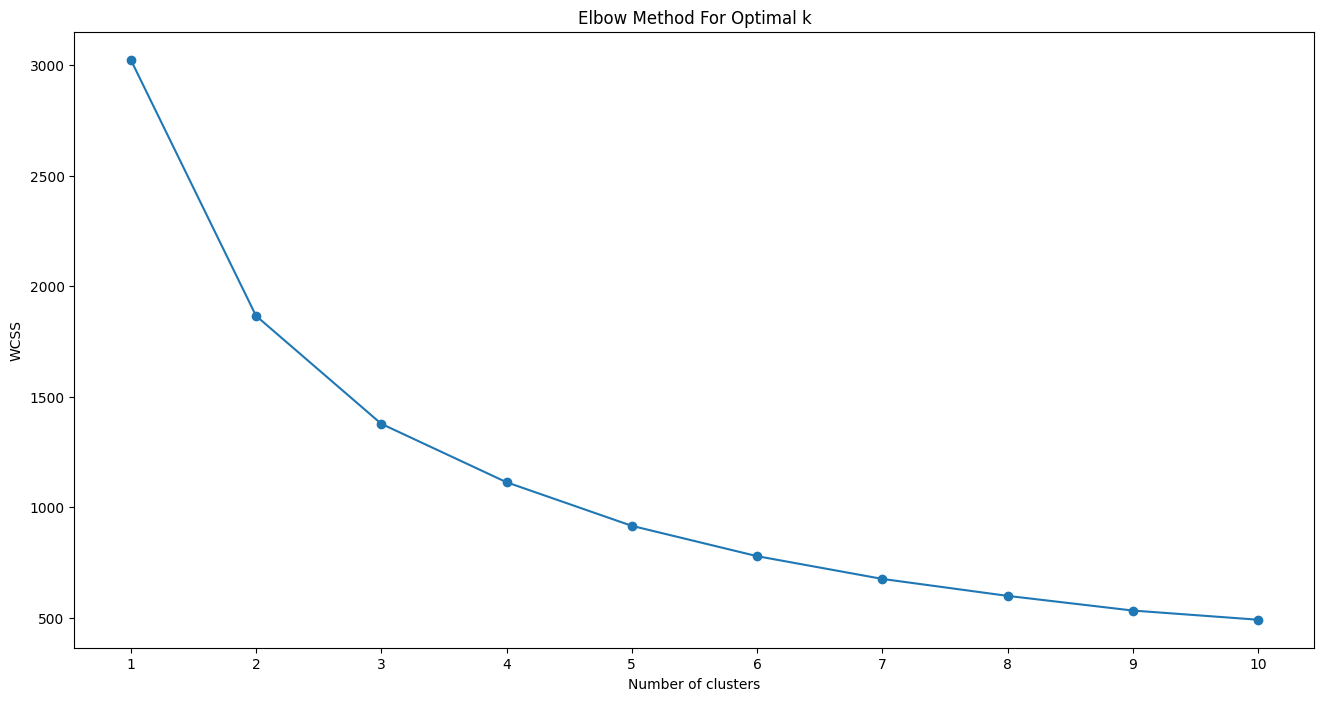

In [21]:
elbow = []
K = range(1,11)
for k in K :
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100).fit(cluster_bac_sexe_pad)
    elbow.append(kmeanElbow.inertia_)

plt.figure(figsize=(16,8), dpi=600)
plt.figure(figsize=(16,8))

plt.plot(K, elbow, marker='o')
plt.xlabel('Number of clusters')
plt.xticks(range(1,11))
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

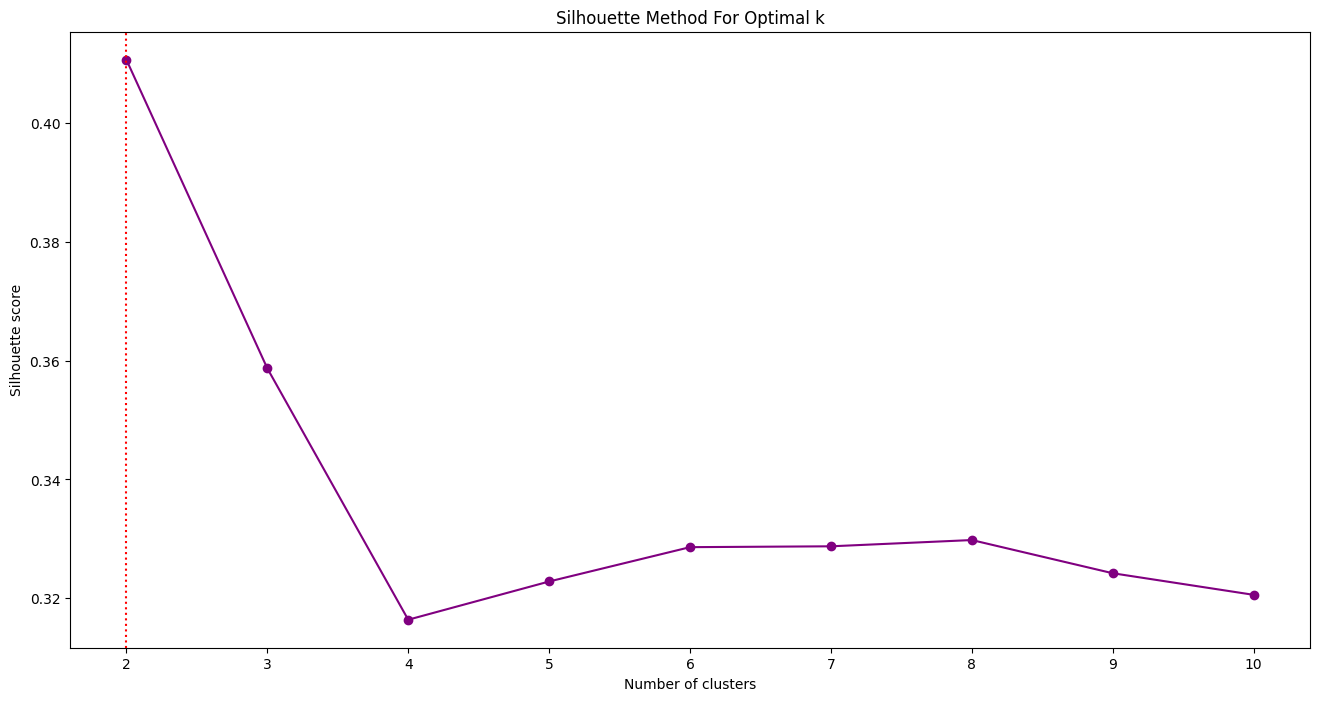

In [22]:
silhouette = []
I = range (2,11)
for i in I:
  kmeansSilhouette = KMeans(n_clusters=i, init='random', random_state=100).fit(cluster_bac_sexe_pad)
  silhouette.append(silhouette_score(cluster_bac_sexe_pad, kmeansSilhouette.labels_))

plt.figure(figsize=(16,8))
plt.plot(range(2,11), silhouette,color = 'purple', marker ='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method For Optimal k')
plt.axvline(x=silhouette.index(max(silhouette))+2, linestyle='dotted',color='red')
plt.show()

In [23]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

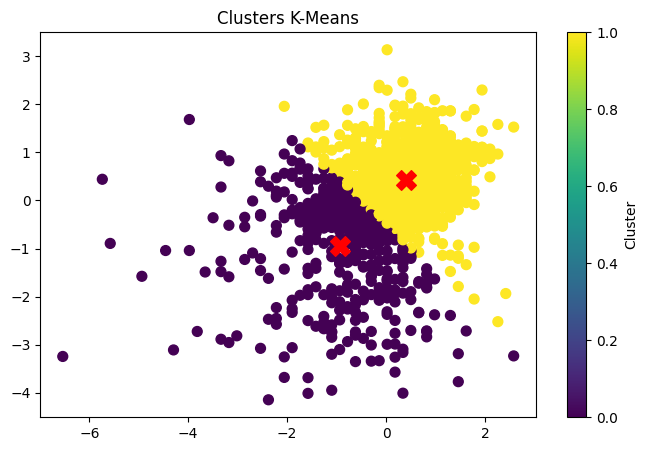

In [24]:
kmeans_bac_sexe = KMeans(n_clusters = 2, init = 'random',random_state=100).fit(cluster_bac_sexe_pad)

plt.figure(figsize=(8,5))
plt.scatter(cluster_bac_sexe_pad.iloc[:, 0], cluster_bac_sexe_pad.iloc[:, 1], c=kmeans_bac_sexe.labels_, s=50, cmap='viridis')  # Pontos coloridos por cluster
plt.scatter(kmeans_bac_sexe.cluster_centers_[:, 0], kmeans_bac_sexe.cluster_centers_[:, 1],
            s=200, c='red', marker='X')  # Centroides em vermelho
plt.colorbar(label="Cluster")
plt.xlabel
plt.ylabel
plt.title('Clusters K-Means')
plt.show()

In [25]:
kmeans_final =KMeans(n_clusters=2, init='random',random_state=100).fit(cluster_bac_sexe_pad)

kmeans_clusters = kmeans_final.labels_
cluster_bac_sexe['Cluster']= kmeans_clusters
cluster_bac_sexe_pad['Cluster'] = kmeans_clusters
cluster_bac_sexe['Cluster']= cluster_bac_sexe['Cluster'].astype('category')
cluster_bac_sexe_pad['Cluster'] = cluster_bac_sexe['Cluster'].astype('category')

In [26]:
print(cluster_bac_sexe)

      Taux d'accès 2nde-bac  prop_filles Cluster
0                        85    38.654618       1
2                        78    57.816006       1
3                        86    47.945205       1
4                        74    37.869822       0
5                        85    43.976494       1
...                     ...          ...     ...
1538                     89    60.813953       1
1539                     90    42.213115       1
1540                     90    38.509317       1
1541                     97    54.789272       1
1542                     76    43.535396       0

[1513 rows x 3 columns]


In [27]:
cluster_bac_sexe.groupby('Cluster')[["Taux d'accès 2nde-bac", 'prop_filles']].mean()

/tmp/ipykernel_582/2098538469.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_bac_sexe.groupby('Cluster')[["Taux d'accès 2nde-bac", 'prop_filles']].mean()


,Taux d'accès 2nde-bac,prop_filles
Cluster,,
0,78.086580,34.337621
1,86.403425,48.140122


In [28]:
cluster_bac_sexe_pad.groupby('Cluster')[["Taux d'accès 2nde-bac", 'prop_filles']].mean()

/tmp/ipykernel_582/3548219455.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_bac_sexe_pad.groupby('Cluster')[["Taux d'accès 2nde-bac", 'prop_filles']].mean()


,Taux d'accès 2nde-bac,prop_filles
Cluster,,
0,-0.924070,-0.942517
1,0.406204,0.414313


In [29]:
cluster_bac_sexe_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1513 entries, 0 to 1542
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Taux d'accès 2nde-bac  1513 non-null   int64  
 1   prop_filles            1513 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 35.5 KB


In [30]:
print(cluster_bac_sexe_num)

      Taux d'accès 2nde-bac  prop_filles
0                        85    38.654618
2                        78    57.816006
3                        86    47.945205
4                        74    37.869822
5                        85    43.976494
...                     ...          ...
1538                     89    60.813953
1539                     90    42.213115
1540                     90    38.509317
1541                     97    54.789272
1542                     76    43.535396

[1513 rows x 2 columns]


In [31]:
cluster_bac_sexe_num.describe()

,Taux d'accès 2nde-bac,prop_filles
count,1513.000000,1513.000000
mean,83.863847,43.925479
std,6.251981,10.172607
min,43.000000,1.777778
25%,81.000000,40.422078
50%,85.000000,45.277361
75%,88.000000,49.914237
max,100.000000,75.777414


In [32]:
!pip install matplotlib
!pip install seaborn
!pip install statsmodels

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

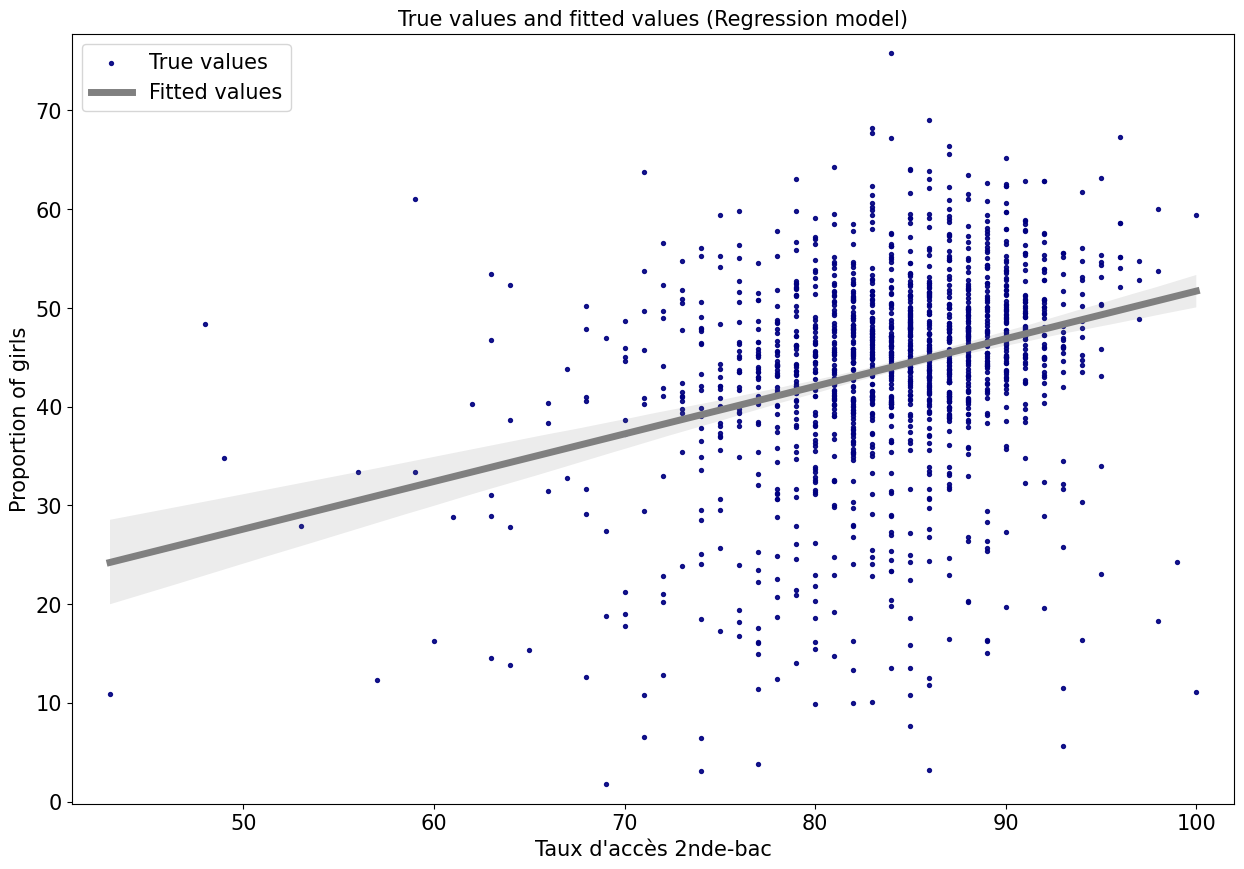

In [34]:
plt.figure(figsize=(15,10))
sns.regplot(data = cluster_bac_sexe_num, x = "Taux d'accès 2nde-bac", y = 'prop_filles', marker = 'o', ci = 95,
            scatter_kws={'color':'navy', 'alpha': 0.9, 's': 8},
            line_kws={"color":"grey", 'linewidth':5})
plt.title('True values and fitted values (Regression model)', fontsize=15)
plt.xlabel("Taux d'accès 2nde-bac", fontsize=15)
plt.ylabel("Proportion of girls", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(cluster_bac_sexe_num["Taux d'accès 2nde-bac"].min() - 2,
         cluster_bac_sexe_num["Taux d'accès 2nde-bac"].max() + 2)

plt.ylim(cluster_bac_sexe_num["prop_filles"].min() - 2,
         cluster_bac_sexe_num["prop_filles"].max() + 2)
plt.legend(['True values', 'Fitted values'], fontsize=15, loc='upper left')
plt.show()

In [35]:
model = sm.OLS.from_formula("prop_filles ~ Q(\"Taux d'accès 2nde-bac\")", data=cluster_bac_sexe_num).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            prop_filles   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     145.5
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           4.76e-32
Time:                        06:50:31   Log-Likelihood:                -5586.5
No. Observations:                1513   AIC:                         1.118e+04
Df Residuals:                    1511   BIC:                         1.119e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      3.4874      3.362      1.037      0.300      -3.107      10.082
Q("Taux d'accès 2nde-bac")     0.4822      0.040     12.061      0.000       0.404       0.561
==============================================================================
Omnibus:                      268.752   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              578.347
Skew:                          -1.014   Prob(JB):                    2.59e-126
Kurtosis:                       5.249   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [36]:
(cluster_bac_sexe_num[["prop_filles", "Taux d'accès 2nde-bac"]].corr())**2

,prop_filles,Taux d'accès 2nde-bac
prop_filles,1.000000,0.087822
Taux d'accès 2nde-bac,0.087822,1.000000


In [37]:
cluster_bac_sexe_num['yhat'] = model.fittedvalues

In [38]:
cluster_bac_sexe_num['eror'] = model.resid

In [39]:
model.params

,0
Intercept,3.487449
"Q(""Taux d'accès 2nde-bac"")",0.482187


In [40]:
print(cluster_bac_sexe_num)

      Taux d'accès 2nde-bac  prop_filles       yhat       eror
0                        85    38.654618  44.473317  -5.818698
2                        78    57.816006  41.098010  16.717996
3                        86    47.945205  44.955503   2.989702
4                        74    37.869822  39.169263  -1.299441
5                        85    43.976494  44.473317  -0.496823
...                     ...          ...        ...        ...
1538                     89    60.813953  46.402063  14.411890
1539                     90    42.213115  46.884250  -4.671135
1540                     90    38.509317  46.884250  -8.374933
1541                     97    54.789272  50.259557   4.529715
1542                     76    43.535396  40.133637   3.401760

[1513 rows x 4 columns]


In [41]:
model_2 = sm.OLS.from_formula("yhat ~ Q(\"Taux d'accès 2nde-bac\")", data=cluster_bac_sexe_num).fit()

In [42]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   yhat   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.261e+31
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        06:50:47   Log-Likelihood:                 44821.
No. Observations:                1513   AIC:                        -8.964e+04
Df Residuals:                    1511   BIC:                        -8.963e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      3.4874   1.14e-14   3.05e+14      0.000       3.487       3.487
Q("Taux d'accès 2nde-bac")     0.4822   1.36e-16   3.55e+15      0.000       0.482       0.482
==============================================================================
Omnibus:                       72.039   Durbin-Watson:                   0.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.554
Skew:                          -0.544   Prob(JB):                     1.95e-18
Kurtosis:                       3.333   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
from statsmodels.stats.anova import anova_lm
anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
"Q(""Taux d'accès 2nde-bac"")",1.0,13740.974868,13740.974868,145.474186,4.761965e-32
Residual,1511.0,142723.692715,94.456448,NaN,NaN


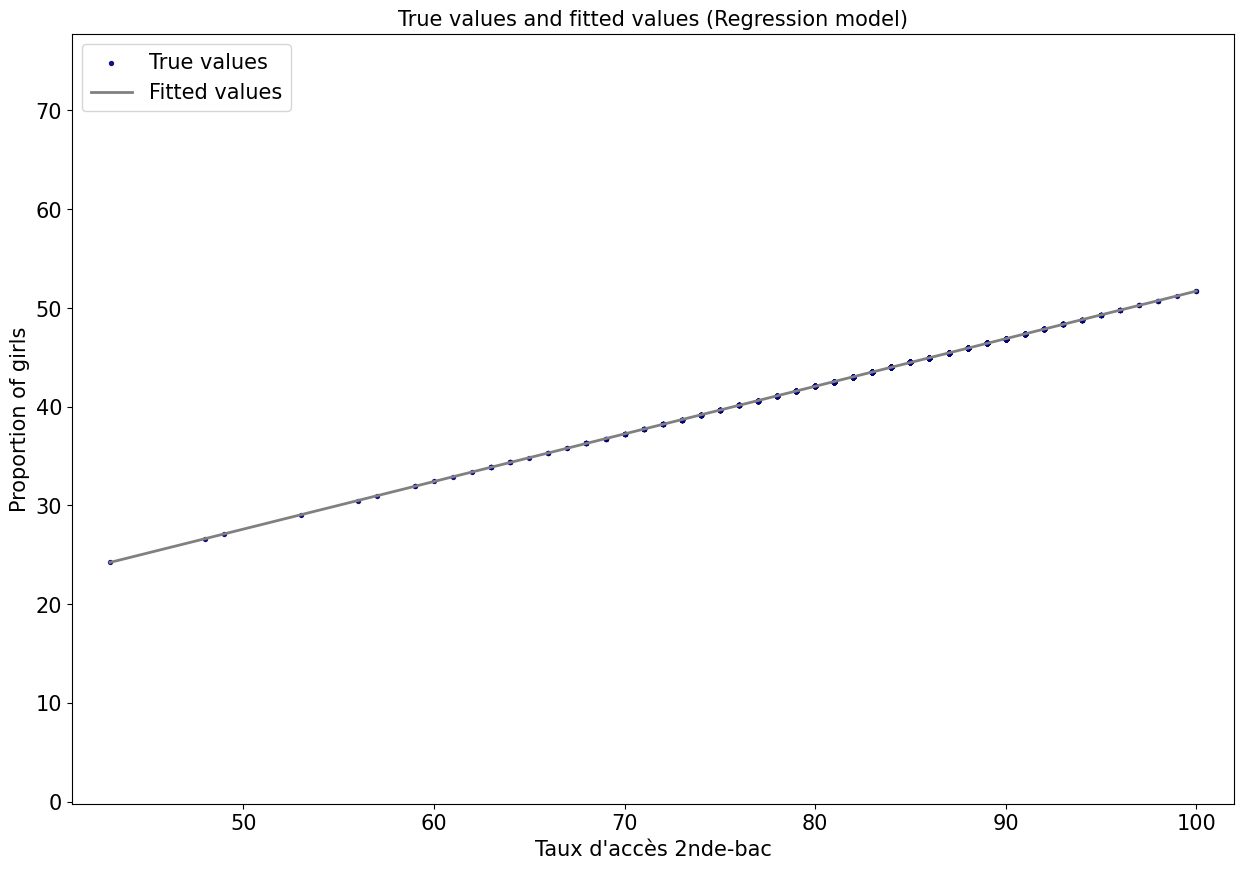

In [44]:
plt.figure(figsize=(15,10))
sns.regplot(data = cluster_bac_sexe_num, x = "Taux d'accès 2nde-bac", y = 'yhat', marker = 'o', ci = False,
            scatter_kws={'color':'navy', 'alpha': 0.9, 's': 8},
            line_kws={"color":"grey", 'linewidth':2})
plt.title('True values and fitted values (Regression model)', fontsize=15)
plt.xlabel("Taux d'accès 2nde-bac", fontsize=15)
plt.ylabel("Proportion of girls", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(cluster_bac_sexe_num["Taux d'accès 2nde-bac"].min() - 2,
         cluster_bac_sexe_num["Taux d'accès 2nde-bac"].max() + 2)

plt.ylim(cluster_bac_sexe_num["prop_filles"].min() - 2,
         cluster_bac_sexe_num["prop_filles"].max() + 2)
plt.legend(['True values', 'Fitted values'], fontsize=15, loc='upper left')
plt.show()